# Client clustering by web interests

## 1. Setup

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Load data

In [3]:
DATA_DIR = Path("data")
clients = pd.read_csv(DATA_DIR / "clients.csv", sep=";")
activity = pd.read_csv(DATA_DIR / "activity.csv", sep=";")
websites = pd.read_csv(DATA_DIR / "websites.csv", sep=";")
categories = pd.read_csv(DATA_DIR / "categories.csv", sep=";")
regions = pd.read_csv(DATA_DIR / "regions.csv", sep=";")

print("Table sizes:")
for name, df in [("clients", clients), ("activity", activity), ("websites", websites), 
                 ("categories", categories), ("regions", regions)]:
    print(f"  {name}: {len(df):,} rows")

Table sizes:
  clients: 50,000 rows
  activity: 1,200,000 rows
  websites: 1,251 rows
  categories: 30 rows
  regions: 23 rows


In [4]:
websites["category_id"] = websites["category_id"].astype(int)

activity_categories = activity.merge(websites, on="website", how="inner")
activity_categories = activity_categories.merge(categories, left_on="category_id", right_on="id", how="inner")

clients_full = clients.merge(regions, left_on="region_id", right_on="id", how="left", suffixes=("", "_region"))

clients_in_activity = activity["client_id"].unique()
clients_in_clients = set(clients["id"])
orphan_activity = activity[~activity["client_id"].isin(clients_in_clients)]
print(f"Activity rows with unknown client_id: {len(orphan_activity)}")

user_category_counts = activity_categories.groupby(["client_id", "category_id", "name"]).size().reset_index(name="visits")
user_category_counts.rename(columns={"name": "category_name"}, inplace=True)
print(f"\nUnique clients with activity: {user_category_counts['client_id'].nunique():,}")

Activity rows with unknown client_id: 0

Unique clients with activity: 42,796


## 3. Data validation

In [5]:
print("Missing values:")
for name, df in [("clients", clients), ("activity", activity), ("websites", websites)]:
    print(f"  {name}:\n{df.isnull().sum()}\n")

print("Duplicates:")
print(f"  clients (by id): {clients.duplicated(subset=['id']).sum()}")
print(f"  activity (client_id + website): {activity.duplicated(subset=['client_id', 'website']).sum()}")

print("\nClient anomalies:")
print(f"  Age: min={clients['age'].min()}, max={clients['age'].max()}")
print(f"  Gender: {clients['gender'].unique()}")
print(f"  region_id: {sorted(clients['region_id'].unique())}")

sites_in_activity = set(activity["website"])
sites_in_websites = set(websites["website"])
sites_without_category = sites_in_activity - sites_in_websites
print(f"\nActivity sites without category: {len(sites_without_category)}")
if sites_without_category:
    print(f"  Examples: {list(sites_without_category)[:5]}")

Missing values:
  clients:
id            0
age           0
gender       82
region_id     0
dtype: int64

  activity:
client_id    0
website      0
dtype: int64

  websites:
website        0
category_id    0
dtype: int64

Duplicates:
  clients (by id): 0
  activity (client_id + website): 90676

Client anomalies:
  Age: min=16, max=80
  Gender: ['F' 'M' nan]
  region_id: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Activity sites without category: 8782
  Examples: ['novatehno.ru', 'greeninsure.shop', 'style-center.com', 'insurefood.net', 'petslearn.shop']


## 4. Exploratory Data Analysis

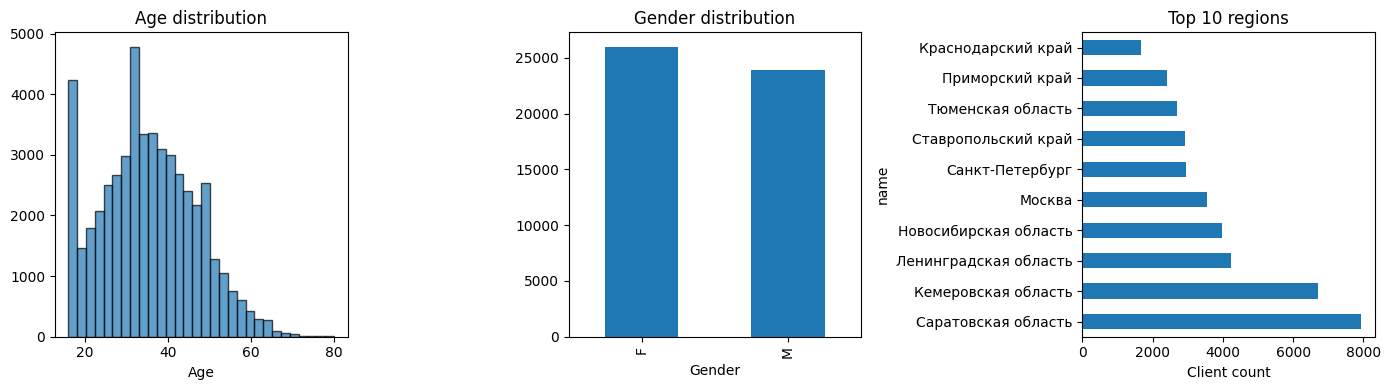

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(clients["age"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")

clients["gender"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Gender distribution")
axes[1].set_xlabel("Gender")

top_regions = clients_full["name"].value_counts().head(10)
top_regions.plot(kind="barh", ax=axes[2])
axes[2].set_title("Top 10 regions")
axes[2].set_xlabel("Client count")
plt.tight_layout()
plt.show()

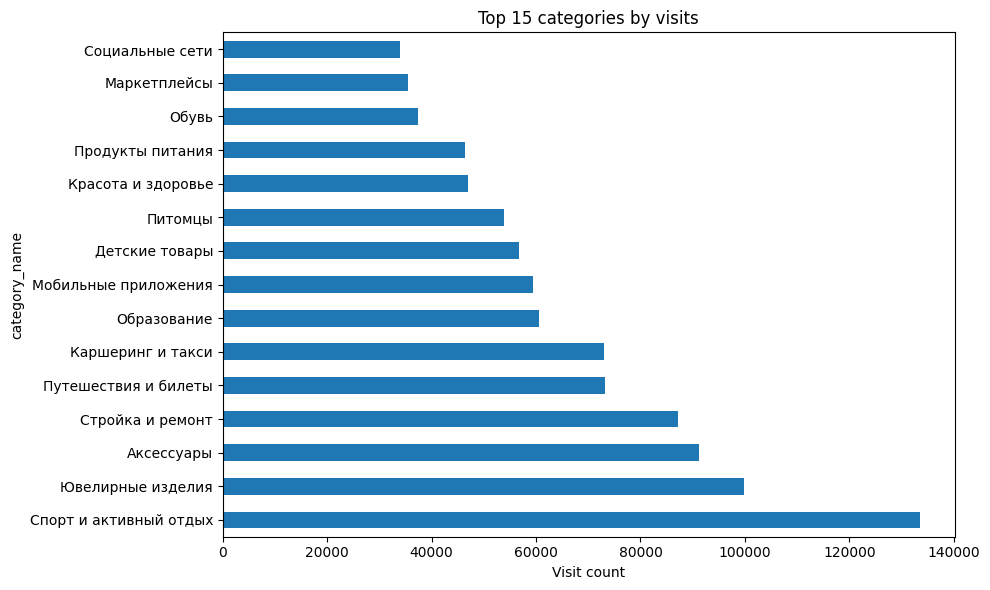

In [7]:
category_traffic = user_category_counts.groupby("category_name")["visits"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
category_traffic.head(15).plot(kind="barh")
plt.title("Top 15 categories by visits")
plt.xlabel("Visit count")
plt.tight_layout()
plt.show()

In [8]:
visits_per_client = activity_categories.groupby("client_id")["website"].count()
print("Visits per client:")
print(visits_per_client.describe())

Visits per client:
count    42796.000000
mean        32.373166
std         17.373036
min          5.000000
25%         20.000000
50%         31.000000
75%         42.000000
max        152.000000
Name: website, dtype: float64


## 5. Feature matrix

In [9]:
user_cat_matrix = user_category_counts.pivot_table(
    index="client_id", columns="category_name", values="visits", fill_value=0
)

row_sums = user_cat_matrix.sum(axis=1)
user_cat_proportions = user_cat_matrix.div(row_sums, axis=0)

print(f"Matrix shape: {user_cat_proportions.shape}")
print(f"Clients: {user_cat_proportions.shape[0]}, categories {user_cat_proportions.shape[1]}")

Matrix shape: (42796, 29)
Clients: 42796, categories 29


In [10]:
min_visits = 5
clients_with_activity = activity_categories.groupby("client_id").size()
active_clients = clients_with_activity[clients_with_activity >= min_visits].index
user_cat_proportions_filtered = user_cat_proportions.loc[user_cat_proportions.index.isin(active_clients)]
print(f"After filter (min {min_visits} visits): {len(user_cat_proportions_filtered):,} clients")

X = user_cat_proportions_filtered.values
client_ids = user_cat_proportions_filtered.index.tolist()
category_names = user_cat_proportions_filtered.columns.tolist()

After filter (min 5 visits): 42,796 clients


## 6. K-means clustering

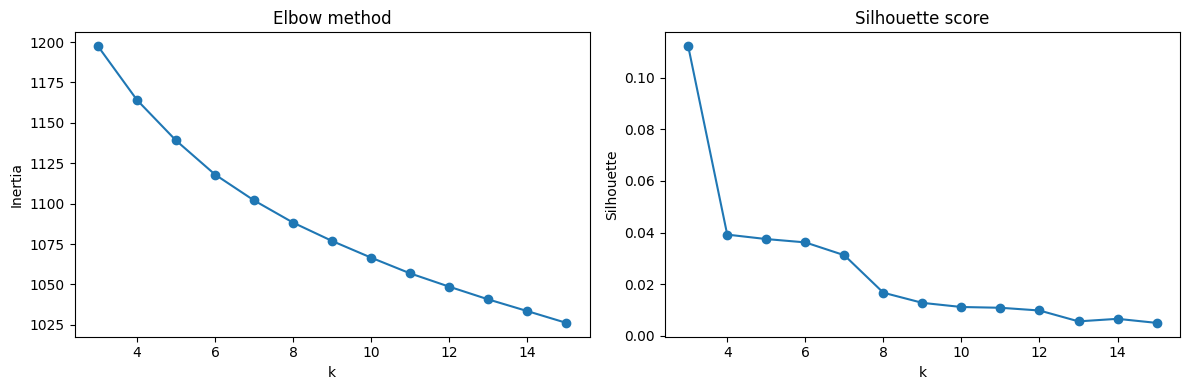

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(3, 16)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, "o-")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [12]:
k_optimal = 8
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
print(f"K-means: k={k_optimal}, silhouette={silhouette_score(X, labels_kmeans):.4f}")

K-means: k=8, silhouette=0.0166


In [13]:
labels_final = labels_kmeans
df_results = pd.DataFrame({
    "client_id": client_ids,
    "cluster": labels_final
})

## 7. Cluster profiles

In [14]:
cluster_profiles = pd.DataFrame(X, columns=category_names, index=client_ids)
cluster_profiles["cluster"] = labels_final

mean_by_cluster = cluster_profiles.groupby("cluster")[category_names].mean()

print("Top 5 categories per cluster:")
for c in mean_by_cluster.index:
    top5 = mean_by_cluster.loc[c].nlargest(5)
    print(f"  Cluster {c}: {', '.join([f'{k} ({v:.3f})' for k, v in top5.items()])}")

Top 5 categories per cluster:
  Cluster 0: Стройка и ремонт (0.123), Спорт и активный отдых (0.106), Путешествия и билеты (0.091), Ювелирные изделия (0.076), Аксессуары (0.060)
  Cluster 1: Аксессуары (0.136), Спорт и активный отдых (0.095), Ювелирные изделия (0.080), Каршеринг и такси (0.051), Стройка и ремонт (0.049)
  Cluster 2: Спорт и активный отдых (0.277), Ювелирные изделия (0.092), Каршеринг и такси (0.060), Аксессуары (0.060), Стройка и ремонт (0.045)
  Cluster 3: Каршеринг и такси (0.152), Спорт и активный отдых (0.128), Ювелирные изделия (0.083), Аксессуары (0.060), Стройка и ремонт (0.045)
  Cluster 4: Спорт и активный отдых (0.066), Ювелирные изделия (0.064), Стройка и ремонт (0.062), Аксессуары (0.060), Путешествия и билеты (0.052)
  Cluster 5: Ювелирные изделия (0.183), Спорт и активный отдых (0.121), Аксессуары (0.057), Каршеринг и такси (0.054), Стройка и ремонт (0.047)
  Cluster 6: Спорт и активный отдых (0.155), Ювелирные изделия (0.060), Аксессуары (0.057), Стройка 

## 8. Demographics by cluster

Gender distribution, 

In [15]:
df_demography = df_results.merge(
    clients_full[["id", "age", "gender", "region_id", "name"]],
    left_on="client_id", right_on="id", how="left"
)
df_demography.rename(columns={"name": "region_name"}, inplace=True)

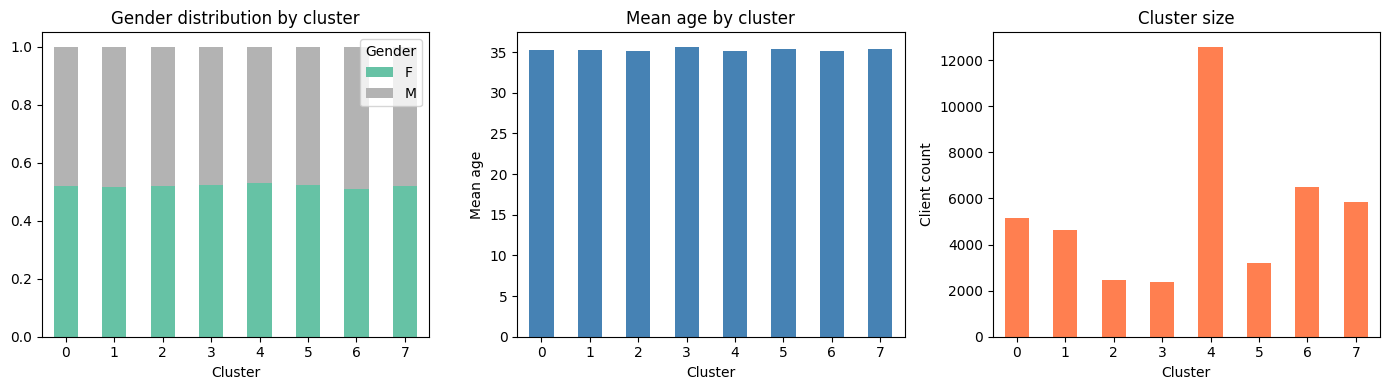

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

gender_by_cluster = pd.crosstab(df_demography["cluster"], df_demography["gender"], normalize="index")
gender_by_cluster.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Gender distribution by cluster")
axes[0].set_xlabel("Cluster")
axes[0].legend(title="Gender")
axes[0].tick_params(axis="x", rotation=0)

age_by_cluster = df_demography.groupby("cluster")["age"].mean()
age_by_cluster.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Mean age by cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Mean age")
axes[1].tick_params(axis="x", rotation=0)

cluster_sizes = df_demography["cluster"].value_counts().sort_index()
cluster_sizes.plot(kind="bar", ax=axes[2], color="coral")
axes[2].set_title("Cluster size")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Client count")
axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [17]:
region_by_cluster = pd.crosstab(df_demography["cluster"], df_demography["region_name"])
region_pct = region_by_cluster.div(region_by_cluster.sum(axis=1), axis=0)

print("Top 3 regions per cluster:")
for c in region_pct.index:
    top3 = region_pct.loc[c].nlargest(3)
    print(f"  Cluster {c}: {', '.join([f'{k} ({v:.2%})' for k, v in top3.items()])}")

Top 3 regions per cluster:
  Cluster 0: Саратовская область (15.86%), Кемеровская область (13.78%), Ленинградская область (8.97%)
  Cluster 1: Саратовская область (15.45%), Кемеровская область (13.58%), Ленинградская область (9.06%)
  Cluster 2: Саратовская область (16.16%), Кемеровская область (14.00%), Ленинградская область (8.63%)
  Cluster 3: Саратовская область (15.62%), Кемеровская область (12.07%), Ленинградская область (8.90%)
  Cluster 4: Саратовская область (16.12%), Кемеровская область (13.45%), Ленинградская область (8.44%)
  Cluster 5: Саратовская область (15.14%), Кемеровская область (13.55%), Ленинградская область (8.66%)
  Cluster 6: Саратовская область (16.19%), Кемеровская область (13.27%), Ленинградская область (7.97%)
  Cluster 7: Саратовская область (15.97%), Кемеровская область (12.96%), Ленинградская область (8.20%)


## 9. Visualizations

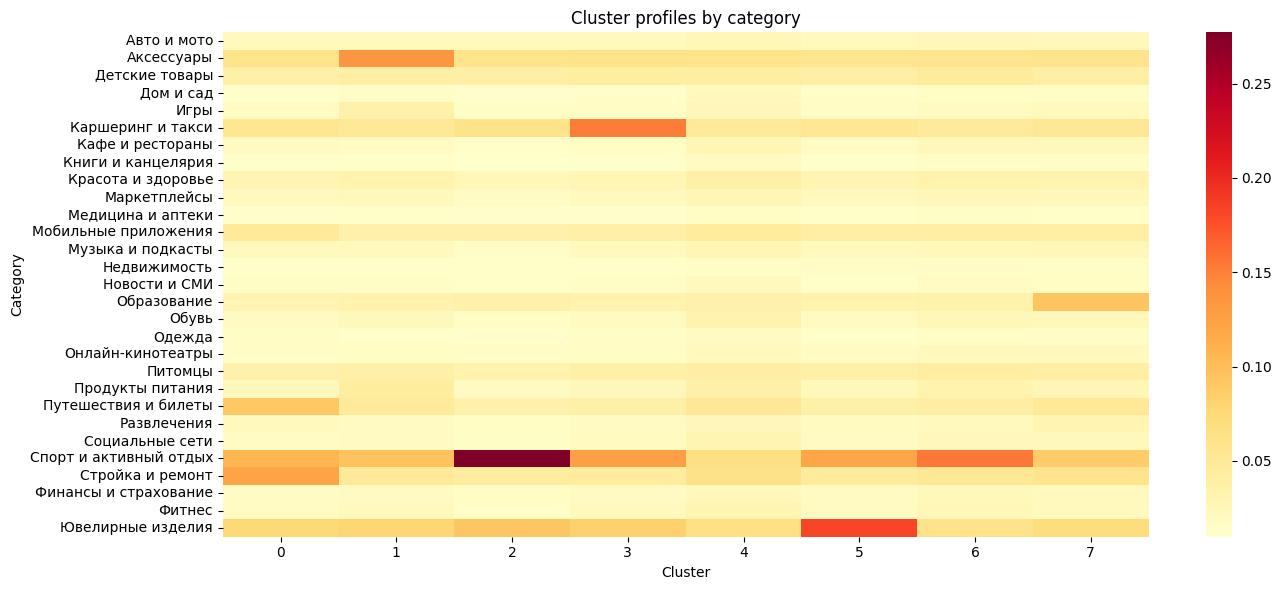

In [18]:
plt.figure(figsize=(14, 6))
sns.heatmap(mean_by_cluster.T, cmap="YlOrRd", xticklabels=True, yticklabels=True)
plt.title("Cluster profiles by category")
plt.xlabel("Cluster")
plt.ylabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

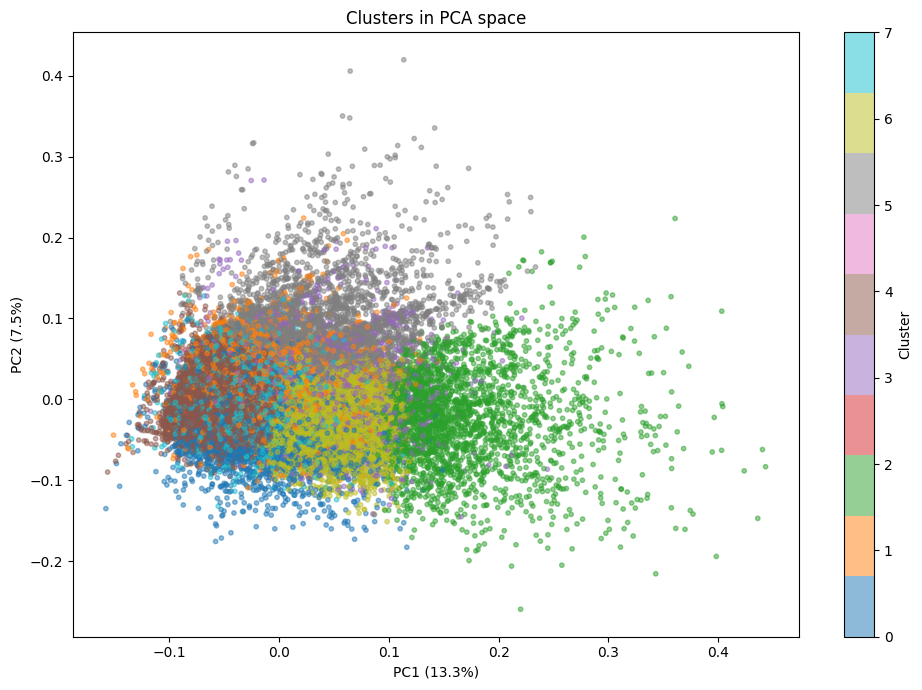

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final, cmap="tab10", alpha=0.5, s=10)
plt.colorbar(scatter, label="Cluster")
plt.title("Clusters in PCA space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()

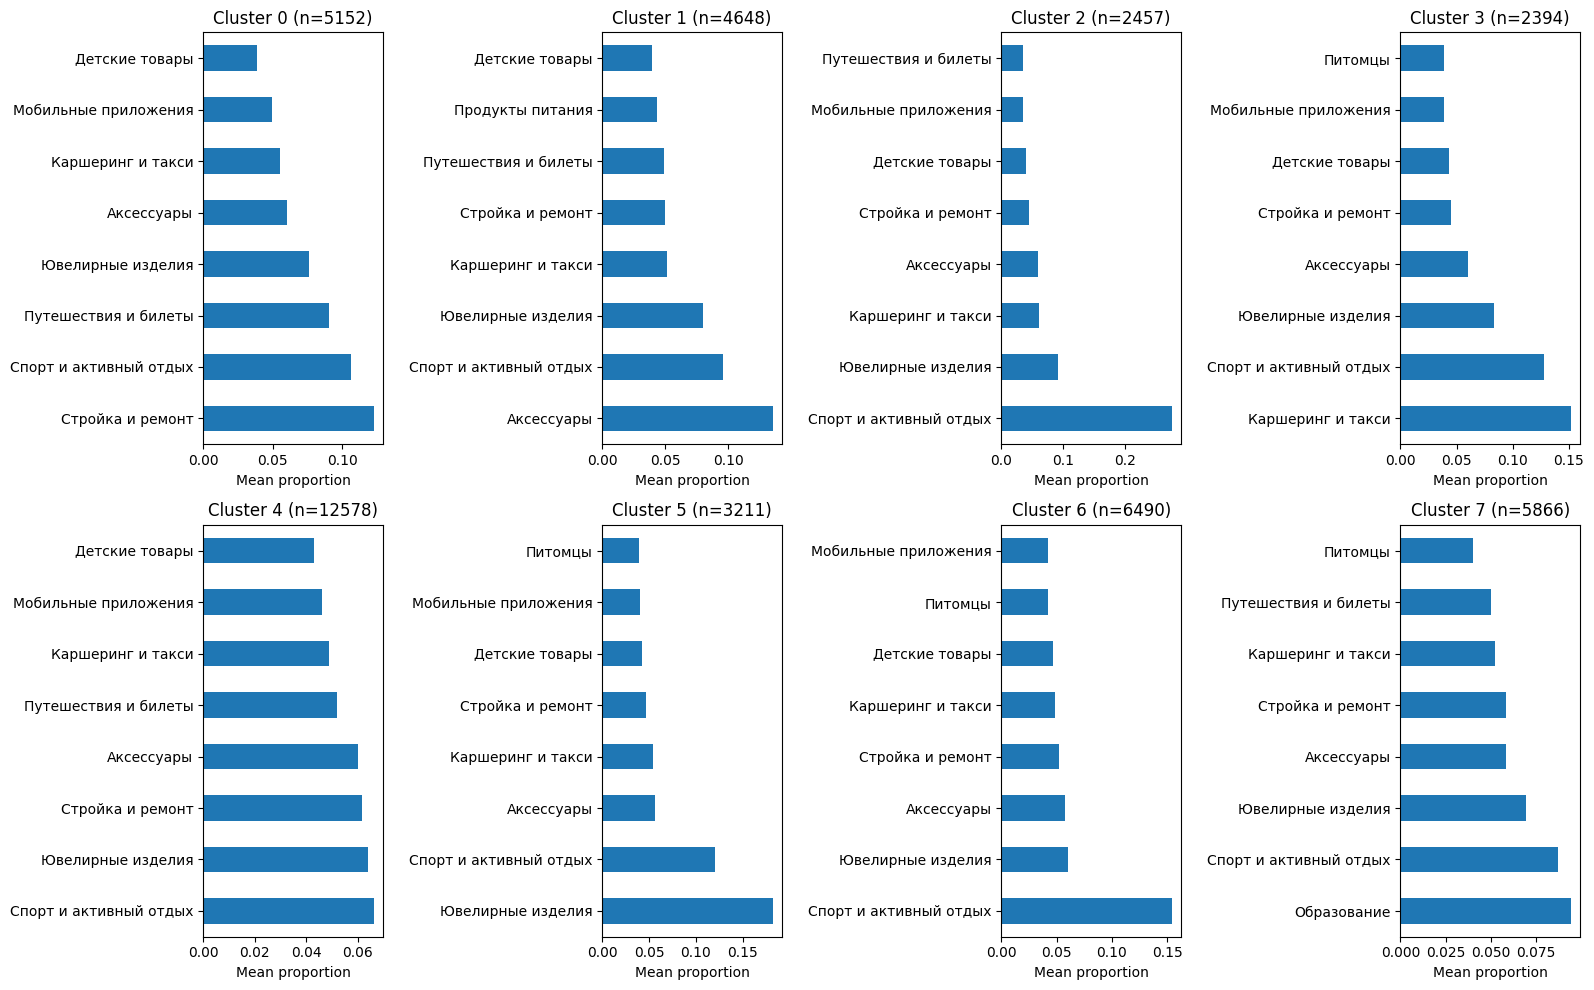

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()
for i, c in enumerate(mean_by_cluster.index):
    top_cats = mean_by_cluster.loc[c].nlargest(8)
    top_cats.plot(kind="barh", ax=axes[i])
    axes[i].set_title(f"Cluster {c} (n={cluster_sizes.get(c, 0)})")
    axes[i].set_xlabel("Mean proportion")
plt.tight_layout()
plt.show()

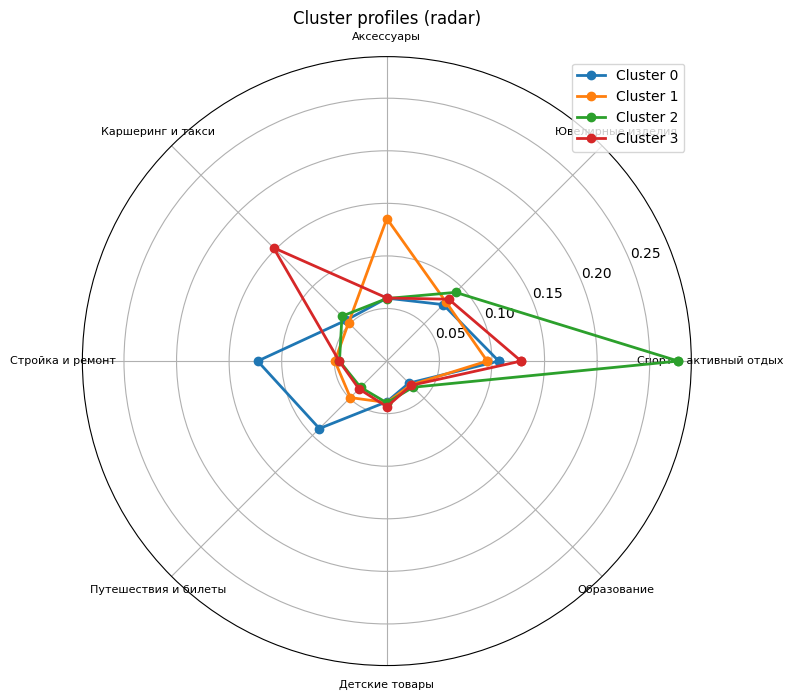

In [21]:
def plot_radar(cluster_ids, categories_to_show=10):
    angles = np.linspace(0, 2*np.pi, categories_to_show, endpoint=False).tolist()
    angles += angles[:1]  # close
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))
    top_cats = mean_by_cluster.sum().nlargest(categories_to_show).index.tolist()
    
    for c in cluster_ids:
        values = mean_by_cluster.loc[c, top_cats].tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=2, label=f"Cluster {c}")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(top_cats, size=8)
    ax.legend(loc="upper right")
    plt.title("Cluster profiles (radar)")
    plt.tight_layout()
    plt.show()

plot_radar([0, 1, 2, 3], categories_to_show=8)

## 10. Summary

- K-means (k=8) on visit proportions across 30 categories
- 8 segments with interpretable profiles
- Demographics: gender, age, region per cluster

In [22]:
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, "o-")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[1].plot(list(k_range), silhouettes, "o-")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.savefig(OUT_DIR / "elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.close()

plt.figure(figsize=(14, 6))
sns.heatmap(mean_by_cluster.T, cmap="YlOrRd", xticklabels=True, yticklabels=True)
plt.title("Cluster profiles")
plt.xlabel("Cluster")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_clusters.png", dpi=150, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_final, cmap="tab10", alpha=0.5, s=10)
plt.colorbar(scatter, label="Cluster")
plt.title("Clusters in PCA space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.savefig(OUT_DIR / "pca_scatter.png", dpi=150, bbox_inches="tight")
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
gender_by_cluster.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Gender by cluster")
age_by_cluster.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Mean age")
cluster_sizes.plot(kind="bar", ax=axes[2], color="coral")
axes[2].set_title("Cluster size")
plt.tight_layout()
plt.savefig(OUT_DIR / "demography.png", dpi=150, bbox_inches="tight")
plt.close()

print(f"Saved to {OUT_DIR}")

Saved to output


In [23]:
# Report template: data for final report
REPORT_DIR = Path("output/report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH = REPORT_DIR / "report_template.md"

sil_score = silhouette_score(X, labels_final)

lines = [
    "# Шаблон отчета",
    "",
    "## Параметры",
    "",
    f"- k = {k_optimal}",
    f"- silhouette_score = {sil_score:.4f}",
    f"- n_clients = {len(user_cat_proportions_filtered):,}",
    "- min_visits = 5",
    "- random_state = 42",
    "- n_categories = 30",
    "",
    "## Кластеры (размер, средний возраст)",
    "",
]

for c in mean_by_cluster.index:
    n = cluster_sizes.get(c, 0)
    age_mean = age_by_cluster.get(c, 0)
    lines.append(f"- Кластер {c}: n={n:,}, средний возраст={age_mean:.1f}")

lines.extend(["", "## Топ-5 категорий по кластерам", ""])
for c in mean_by_cluster.index:
    top5 = mean_by_cluster.loc[c].nlargest(5)
    cats = ", ".join([f"{k} ({v:.2f})" for k, v in top5.items()])
    lines.append(f"- **Кластер {c}:** {cats}")

lines.extend(["", "## Топ-3 региона по кластерам", ""])
for c in region_pct.index:
    top3 = region_pct.loc[c].nlargest(3)
    regs = ", ".join([f"{k} ({v:.1%})" for k, v in top3.items()])
    lines.append(f"- **Кластер {c}:** {regs}")

lines.extend([
    "",
    "## Пути к графикам",
    "",
    "- output/elbow_silhouette.png",
    "- output/heatmap_clusters.png",
    "- output/pca_scatter.png",
    "- output/demography.png",
    "",
])

REPORT_PATH.write_text("\n".join(lines), encoding="utf-8")
print(f"Template saved to {REPORT_PATH}")

Template saved to output/report/report_template.md
